In [1]:
import numpy as np
from skimage import io
import matplotlib
import matplotlib.pyplot as plt
import os
from glob import glob
import torch
import torch.nn as nn
from tqdm import tqdm
from PIL import Image
from torch.utils.data import DataLoader, Dataset, random_split
from torch.autograd import Variable
if not os.path.exists('./outputs'):
    os.mkdir('./outputs')

In [2]:
# Global parameters

# If USE_CUDA is True, computations will be done using the GPU (may not work in all systems)
# This will make the calculations happen faster
USE_CUDA = torch.cuda.is_available()

DATASET_PATH = '/content/EuroSAT_RGB'

BATCH_SIZE = 64 # Number of images that are used for calculating gradients at each step

NUM_EPOCHS = 25 # Number of times we will go through all the training images. Do not go over 25

LEARNING_RATE = 0.001 # Controls the step size
MOMENTUM = 0.9 # Momentum for the gradient descent
WEIGHT_DECAY = 0.0005

In [3]:
# Create datasets and data loaders
# Transformations

from torchvision import datasets, models, transforms
data_transforms = transforms.Compose([
        transforms.Resize(64),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

dataset = datasets.ImageFolder(root='/content/EuroSAT_RGB', transform=data_transforms)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

class_names = dataset.classes

print('Dataloaders OK')
test_loader

for images, labels in test_loader:
    for label in labels:
        print(f'Label Number: {label.item()}, Label Name: {class_names[label.item()]}')
    break  # Remove this line if you want to print for all batches

Dataloaders OK
Label Number: 9, Label Name: SeaLake
Label Number: 2, Label Name: HerbaceousVegetation
Label Number: 2, Label Name: HerbaceousVegetation
Label Number: 8, Label Name: River
Label Number: 8, Label Name: River
Label Number: 1, Label Name: Forest
Label Number: 9, Label Name: SeaLake
Label Number: 9, Label Name: SeaLake
Label Number: 5, Label Name: Pasture
Label Number: 3, Label Name: Highway
Label Number: 4, Label Name: Industrial
Label Number: 5, Label Name: Pasture
Label Number: 0, Label Name: AnnualCrop
Label Number: 3, Label Name: Highway
Label Number: 9, Label Name: SeaLake
Label Number: 7, Label Name: Residential
Label Number: 0, Label Name: AnnualCrop
Label Number: 3, Label Name: Highway
Label Number: 4, Label Name: Industrial
Label Number: 9, Label Name: SeaLake
Label Number: 3, Label Name: Highway
Label Number: 2, Label Name: HerbaceousVegetation
Label Number: 1, Label Name: Forest
Label Number: 4, Label Name: Industrial
Label Number: 5, Label Name: Pasture
Label Nu

Image label: 2


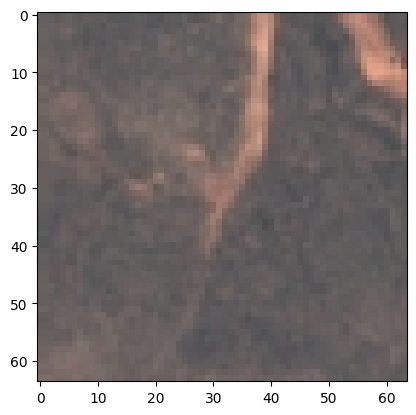

In [ ]:
#Print the corresponding label for the image

random_image = train_dataset[0][0].numpy().transpose((1, 2, 0))
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
random_image = std * random_image + mean
random_image = np.clip(random_image, 0, 1)
print("Image label:", train_dataset[0][1])
plt.imshow(random_image)

# Convolutional Neural Network Architecture

In [ ]:
#Create the model class
class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()
        #Same Padding = [(filter size - 1) / 2] (Same Padding--> input size = output size)
        self.cnn1 = nn.Conv2d(in_channels=3, out_channels=4, kernel_size=3,stride=1, padding=1)
        #The output size of each of the 4 feature maps is
        #[(input_size - filter_size + 2(padding) / stride) +1] --> [(64-3+2(1)/1)+1] = 64 (padding type is same)
        self.batchnorm1 = nn.BatchNorm2d(4)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)

        #After max pooling, the output of each feature map is now 64/2 =32
        self.cnn2 = nn.Conv2d(in_channels=4, out_channels=8, kernel_size=3, stride=1, padding=1)
        #Output size of each of the 32 feature maps
        self.batchnorm2 = nn.BatchNorm2d(8)
        self.maxpool2 = nn.MaxPool2d(kernel_size=2)

        #After max pooling, the output of each feature map is 32/2 = 16
        #Flatten the feature maps. You have 8 feature maps, each of them is of size 16x16 --> 8*16*16 = 2048
        self.fc1 = nn.Linear(in_features=8*16*16, out_features=32)
        self.droput = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(in_features=32, out_features=10)

    def forward(self,x):
        out = self.cnn1(x)
        out = self.batchnorm1(out)
        out = self.relu(out)
        out = self.maxpool1(out)
        out = self.cnn2(out)
        out = self.batchnorm2(out)
        out = self.relu(out)
        out = self.maxpool2(out)

        #Now we have to flatten the output. This is where we apply the feed forward neural network as learned before!
        #It will take the shape (batch_size, 2048)
        out = out.view(x.size(0), -1)

        #Then we forward through our fully connected layer
        out = self.fc1(out)
        out = self.relu(out)
        #out = self.droput(out)
        out = self.fc2(out)
        return out

# Create models

In [ ]:
# Create network
model = CNN()
if USE_CUDA:
    model = model.cuda()

print('Network OK')

Network OK


In [ ]:
# Define criterion, optimizer, and scheduler

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

# Training with CNN



Running epoch 1 of 25...


Epoch 1 validation results: Loss=0.7333793121225693 | Accuracy=73.4074074074074



Running epoch 2 of 25...


Epoch 2 validation results: Loss=0.7096766534973593 | Accuracy=74.48148148148148



/tmp/ipython-input-1133221809.py:77: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  plt.figure(figsize=(12, 8), num=1)




Running epoch 3 of 25...



/tmp/ipython-input-1133221809.py:88: UserWarning: Ignoring specified arguments in this call because figure with num: 2 already exists
  plt.figure(figsize=(12, 8), num=2)



Epoch 3 validation results: Loss=0.7563300234429976 | Accuracy=73.07407407407408



...

/tmp/ipython-input-1133221809.py:77: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  plt.figure(figsize=(12, 8), num=1)
/tmp/ipython-input-1133221809.py:88: UserWarning: Ignoring specified arguments in this call because figure with num: 2 already exists
  plt.figure(figsize=(12, 8), num=2)



Epoch 24 validation results: Loss=0.545098142413532 | Accuracy=80.96296296296296



/tmp/ipython-input-1133221809.py:77: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  plt.figure(figsize=(12, 8), num=1)
/tmp/ipython-input-1133221809.py:88: UserWarning: Ignoring specified arguments in this call because figure with num: 2 already exists
  plt.figure(figsize=(12, 8), num=2)




Running epoch 25 of 25...


Epoch 25 validation results: Loss=0.5431606229613809 | Accuracy=81.0



/tmp/ipython-input-1133221809.py:77: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  plt.figure(figsize=(12, 8), num=1)
/tmp/ipython-input-1133221809.py:88: UserWarning: Ignoring specified arguments in this call because figure with num: 2 already exists
  plt.figure(figsize=(12, 8), num=2)


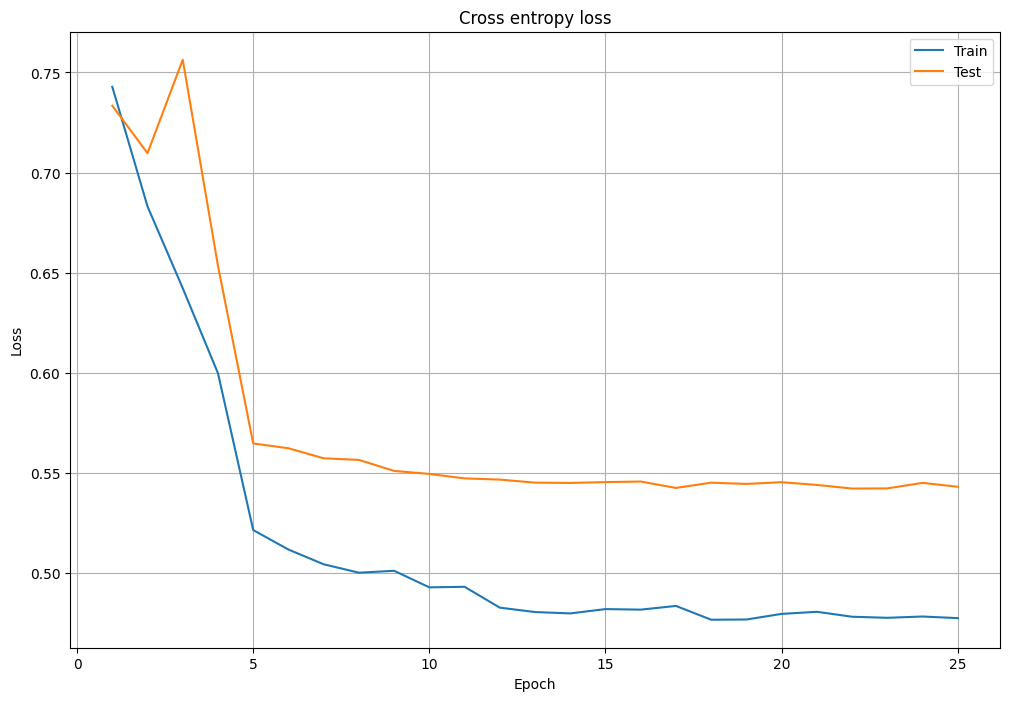

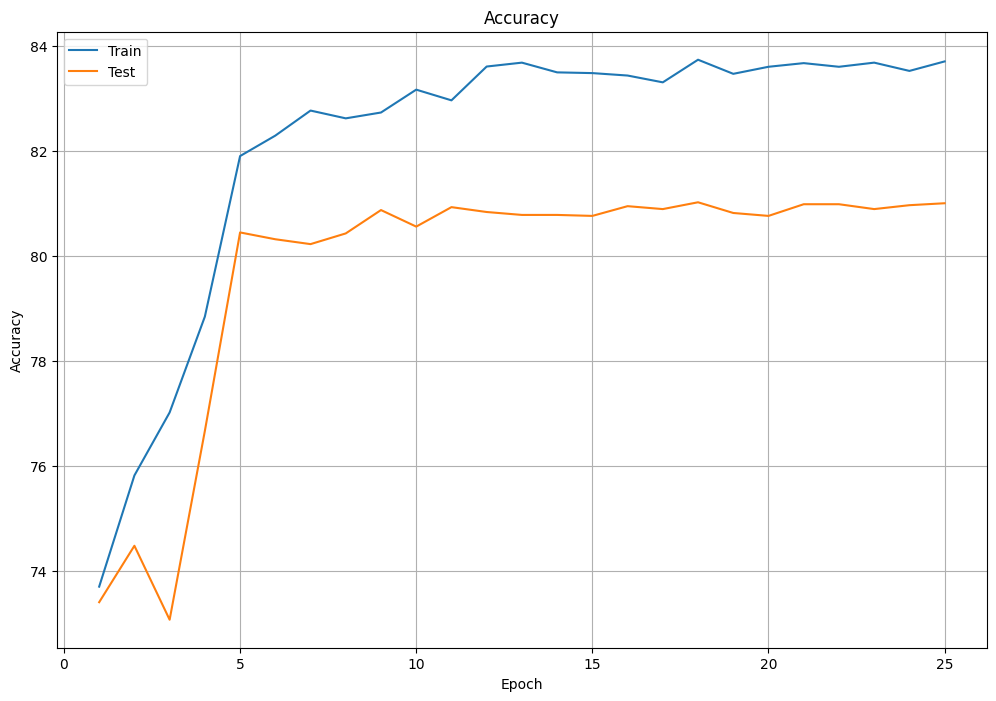

In [ ]:
# Main loop
train_loss = []
train_accuracy = []
test_loss = []
test_accuracy = []
epochs = []

for epoch in range(1, NUM_EPOCHS+1):
    print(f'\n\nRunning epoch {epoch} of {NUM_EPOCHS}...\n')
    epochs.append(epoch)

    #-------------------------Train-------------------------

    #Reset these below variables to 0 at the begining of every epoch
    correct = 0
    iterations = 0
    iter_loss = 0.0

    model.train()  # Put the network into training mode

    for i, (inputs, labels) in enumerate(train_loader):

        if USE_CUDA:
            inputs = inputs.cuda()
            labels = labels.cuda()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        iter_loss += loss.item()  # Accumulate the loss
        optimizer.zero_grad() # Clear off the gradient in (w = w - gradient)
        loss.backward()   # Backpropagation
        optimizer.step()  # Update the weights

        # Record the correct predictions for training data
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().cpu()
        iterations += 1

    scheduler.step()

    # Record the training loss
    train_loss.append(iter_loss/iterations)
    # Record the training accuracy
    train_accuracy.append((100 * correct.item() / len(train_dataset)))

    #-------------------------Test--------------------------

    correct = 0
    iterations = 0
    testing_loss = 0.0

    model.eval()  # Put the network into evaluation mode

    for i, (inputs, labels) in enumerate(test_loader):

        if USE_CUDA:
            inputs = inputs.cuda()
            labels = labels.cuda()

        outputs = model(inputs)
        loss = criterion(outputs, labels) # Calculate the loss
        testing_loss += loss.item()
        # Record the correct predictions for training data
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().cpu()

        iterations += 1

    # Record the Testing loss
    test_loss.append(testing_loss/iterations)
    # Record the Testing accuracy
    test_accuracy.append((100 * correct.item() / len(test_dataset)))

    print(f'\nEpoch {epoch} validation results: Loss={test_loss[-1]} | Accuracy={test_accuracy[-1]}\n')

    # Plot and save
    plt.figure(figsize=(12, 8), num=1)
    plt.clf()
    plt.plot(epochs, train_loss, label='Train')
    plt.plot(epochs, test_loss, label='Test')
    plt.legend()
    plt.grid()
    plt.title('Cross entropy loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.savefig('outputs/01-loss-cnn.pdf')

    plt.figure(figsize=(12, 8), num=2)
    plt.clf()
    plt.plot(epochs, train_accuracy, label='Train')
    plt.plot(epochs, test_accuracy, label='Test')
    plt.legend()
    plt.grid()
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.savefig('outputs/02-accuracy-cnn.pdf')

# Results

In [ ]:
print(f'Final train loss: {train_loss[-1]}')
print(f'Final test loss: {test_loss[-1]}')
print(f'Final train accuracy: {train_accuracy[-1]}')
print(f'Final test accuracy: {test_accuracy[-1]}')

Final train loss: 0.47758920129234267
Final test loss: 0.5431606229613809
Final train accuracy: 83.69907407407408
Final test accuracy: 81.0


In [ ]:
torch.save(model, 'full_model.pth')